In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import chemcoord as cc
import pandas as pd
import matplotlib.pyplot as plt

from ase.io.trajectory import Trajectory
from flonacomldft.internal_coordinates import Coordinates_mapping
from flonacomldft.utils.silver_isomers_utils import (
    get_molecule_isomer_minima,
    get_construction_table
)

In [3]:
# Define the working directory
working_dir = "/home/amolina/ab-flowMC/ag8"
molecular_dynamics_dir = working_dir + "/1-molecular-dynamics"

# 1. Molecular dynamics trajectories

In [4]:
# Load the trajectories
ag8_trajs = {'0': Trajectory(
    molecular_dynamics_dir + "/molecular_dynamics_ag8_0_20240902035647.traj"
    ),
             '1': Trajectory(
    molecular_dynamics_dir + "/molecular_dynamics_ag8_1_20240902065506.traj"
    )}

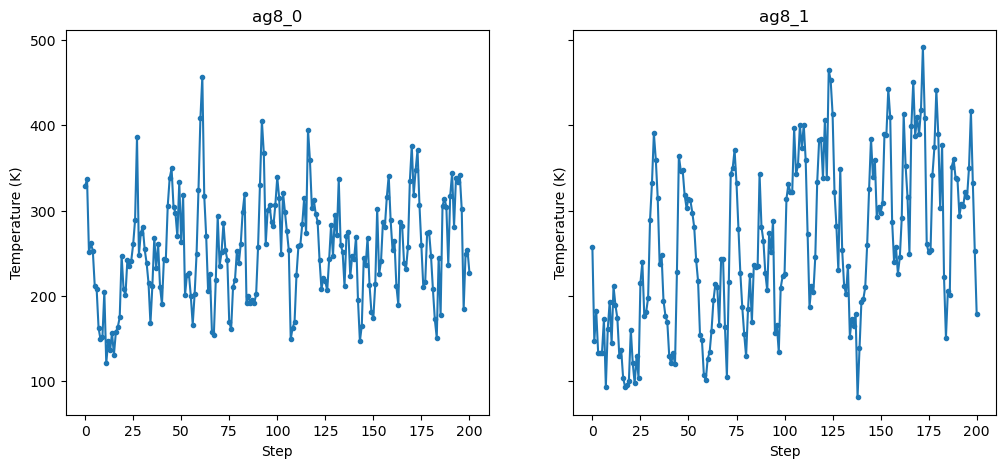

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for i, ag8 in ag8_trajs.items():
    temperature = [atoms.get_temperature() for atoms in ag8]
    axs[int(i)].plot(temperature, '.-')
    axs[int(i)].set_xlabel('Step')
    axs[int(i)].set_ylabel('Temperature (K)')
    axs[int(i)].set_title(f'ag8_{i}')

# 2. Internal coordinates

In [6]:
cartesian = cc.Cartesian.from_ase_atoms(get_molecule_isomer_minima('FD-TPSS', 'ag8', 0))
zmat = cartesian.get_zmat()
construction_table = cartesian.get_construction_table()

print("ZMAT: Internal coordinates for isomer 0 of ag8")
zmat

ZMAT: Internal coordinates for isomer 0 of ag8


,atom,b,bond,a,angle,d,dihedral
6,Ag,$\vec{0}$,13.446089,$\vec{e_z}$,55.647465,$\vec{e_x}$,45.201584
0,Ag,6,2.793928,$\vec{e_z}$,35.249279,$\vec{e_x}$,52.827586
1,Ag,0,2.743090,6,59.293732,$\vec{e_x}$,-88.082961
2,Ag,0,2.742639,1,112.623159,6,27.355776
4,Ag,2,2.737163,0,61.728378,1,-98.553623
5,Ag,4,2.737969,2,112.104411,0,98.635043
7,Ag,5,2.738895,4,61.644410,2,-99.345051
3,Ag,7,2.737317,5,112.029030,4,-27.412233


In [7]:
#coord_maps = Coordinates_mapping(
#                                 calculator_label='LCAO',
#                                 chemical_formula='Ag6',
#                                 etype='dft')

In [8]:
print("Construction table: Using internal coordinates for isomer 0 of ag8 as reference")
construction_table

Construction table: Using internal coordinates for isomer 0 of ag8 as reference


,b,a,d
6,origin,e_z,e_x
0,6,e_z,e_x
1,0,6,e_x
2,0,1,6
4,2,0,1
5,4,2,0
7,5,4,2
3,7,5,4


In [9]:
print("Construction table save in utils.silver_isomers_utils for ag8")
get_construction_table('ag8')

Construction table save in utils.silver_isomers_utils for ag8


,b,a,d
6,origin,e_z,e_x
0,6,e_z,e_x
1,0,6,e_x
2,0,1,6
4,2,0,1
5,4,2,0
7,5,4,2
3,7,5,4


In [13]:
# Coordinates mapping object for ag8

construction_table = get_construction_table('ag8')
coord_maps = Coordinates_mapping(construction_table=construction_table,
                                 calculator_label='FD-TPSS',
                                 chemical_formula='Ag8',
                                 etype='dft')

In [11]:
zmat = coord_maps.zmat_minima[0]
molecule = coord_maps.build_molecule_from_zmat(zmat)
isomer_minima = get_molecule_isomer_minima('FD-TPSS', 'Ag8', '0')

sum_reconstruction_error = (isomer_minima.get_all_distances() - molecule.get_all_distances()).mean()

print(f"Sum of reconstruction error: {sum_reconstruction_error:.2e} Å")

Sum of reconstruction error: -5.06e-08 Å


## 2.a Internal coordinates for MD trajectories

In [18]:
zmats = coord_maps.get_internal_from_trajectory(ag8_trajs['0'][:10], temperature=300)
zmats

# TODO: ADD PLOTS OF VARIABLES

tensor([[  2.8785,   2.7575,   2.7580,   2.7588,   2.7578,   2.7595,   2.7589,
           1.0220,   1.9420,   1.0970,   1.9444,   1.0983,   1.9402,   0.4661,
          -1.7173,   1.7150,  -1.7146,  -0.4648, -65.5875,  13.7154,  18.4520,
           2.3334],
        [  2.8739,   2.7580,   2.7534,   2.7628,   2.7622,   2.7622,   2.7575,
           1.0120,   1.9463,   1.0961,   1.9502,   1.0912,   1.9509,   0.4608,
          -1.7003,   1.7159,  -1.7227,  -0.4720, -65.5847,  13.6977,  18.4353,
           2.3349],
        [  2.8696,   2.7584,   2.7531,   2.7703,   2.7633,   2.7651,   2.7539,
           1.0037,   1.9480,   1.0942,   1.9538,   1.0831,   1.9614,   0.4573,
          -1.6856,   1.7181,  -1.7319,  -0.4771, -65.5794,  13.6836,  18.4417,
           2.3359],
        [  2.8678,   2.7606,   2.7534,   2.7809,   2.7619,   2.7617,   2.7534,
           0.9962,   1.9496,   1.0918,   1.9565,   1.0750,   1.9715,   0.4540,
          -1.6710,   1.7213,  -1.7415,  -0.4814, -65.5706,  13.6716,  1